# RQ3: Model Comparison

**Research question:** How do traditional machine learning models compare with neural network models in predicting short-form video trend labels?

## 1. Setup

In [9]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd

from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, f1_score
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

RANDOM_STATE = 42
TARGET = "trend_label"

pd.set_option("display.max_columns", 100)
warnings.filterwarnings("ignore", category=ConvergenceWarning)


## 2. Load Processed Data

The inputs are already numeric because preprocessing handled categorical encoding. RQ3 uses the full encoded feature matrix for every model so that the comparison isolates model choice rather than feature-group choice.

In [10]:
train = pd.read_csv("../data/processed/train.csv")
validation = pd.read_csv("../data/processed/validation.csv")
test = pd.read_csv("../data/processed/test.csv")

X_train = train.drop(columns=TARGET)
y_train = train[TARGET]

X_val = validation.drop(columns=TARGET)
y_val = validation[TARGET]

X_test = test.drop(columns=TARGET)
y_test = test[TARGET]

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)
print("Non-numeric columns:", X_train.select_dtypes(exclude=["number"]).columns.tolist())

display(y_train.value_counts(normalize=True).sort_index())

Train: (33655, 203) (33655,)
Validation: (7212, 203) (7212,)
Test: (7212, 203) (7212,)
Non-numeric columns: []


trend_label
declining    0.249651
rising       0.251701
seasonal     0.252622
stable       0.246026
Name: proportion, dtype: float64

## 3. Model Set

Feature groups are not varied in this notebook. RQ2 already evaluates feature-group effectiveness, while RQ3 compares traditional models against a neural network on the same full feature set.

In [11]:
models = {
    "Dummy Majority": {
        "type": "baseline",
        "model": DummyClassifier(strategy="most_frequent"),
    },
    "Logistic Regression": {
        "type": "traditional",
        "model": make_pipeline(
            StandardScaler(),
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            ),
        ),
    },
    "Linear SVM": {
        "type": "traditional",
        "model": make_pipeline(
            StandardScaler(),
            LinearSVC(
                class_weight="balanced",
                max_iter=5000,
                random_state=RANDOM_STATE,
            ),
        ),
    },
    "Random Forest": {
        "type": "traditional",
        "model": RandomForestClassifier(
            n_estimators=120,
            min_samples_leaf=5,
            class_weight="balanced_subsample",
            n_jobs=1,
            random_state=RANDOM_STATE,
        ),
    },
    "MLP Neural Network": {
        "type": "neural_network",
        "model": make_pipeline(
            StandardScaler(),
            MLPClassifier(
                hidden_layer_sizes=(64, 32),
                max_iter=80,
                random_state=RANDOM_STATE,
            ),
        ),
    },
}


## 4. Validation Comparison

In [12]:
rows = []
trained_models = {}

for model_name, info in models.items():
    model = info["model"]
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)

    rows.append({
        "model": model_name,
        "type": info["type"],
        "accuracy": accuracy_score(y_val, y_pred),
        "macro_f1": f1_score(y_val, y_pred, average="macro"),
    })
    trained_models[model_name] = model

validation_results = pd.DataFrame(rows).sort_values("macro_f1", ascending=False).reset_index(drop=True)
display(validation_results.round(4))

,model,type,accuracy,macro_f1
0,Random Forest,traditional,0.2528,0.2527
1,MLP Neural Network,neural_network,0.2515,0.2503
2,Linear SVM,traditional,0.2417,0.2412
3,Logistic Regression,traditional,0.2402,0.2399
4,Dummy Majority,baseline,0.2526,0.1008


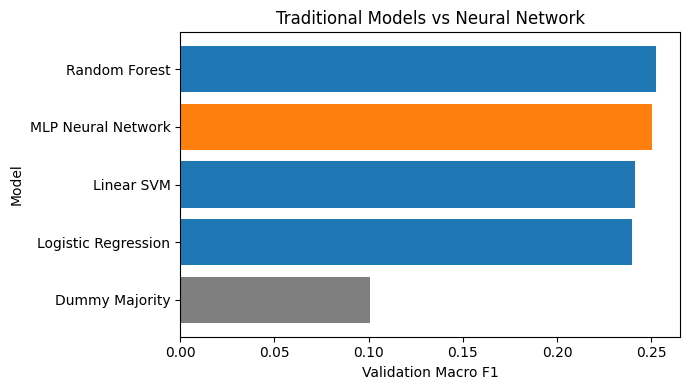

In [13]:
plot_data = validation_results.sort_values("macro_f1")
colors = plot_data["type"].map({
    "baseline": "tab:gray",
    "traditional": "tab:blue",
    "neural_network": "tab:orange",
})

plt.figure(figsize=(7, 4))
plt.barh(plot_data["model"], plot_data["macro_f1"], color=colors)
plt.xlabel("Validation Macro F1")
plt.ylabel("Model")
plt.title("Traditional Models vs Neural Network")
plt.tight_layout()
plt.show()

## 5. Final Test Evaluation

The test set is used only after validation. The final comparison includes the best traditional validation model, the neural network, and the majority baseline.


=== Dummy Majority ===
              precision    recall  f1-score   support

   declining      0.000     0.000     0.000      1801
      rising      0.000     0.000     0.000      1815
    seasonal      0.253     1.000     0.403      1822
      stable      0.000     0.000     0.000      1774

    accuracy                          0.253      7212
   macro avg      0.063     0.250     0.101      7212
weighted avg      0.064     0.253     0.102      7212



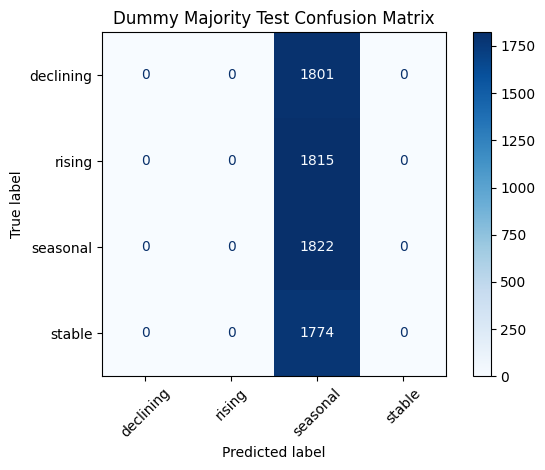


=== Random Forest ===
              precision    recall  f1-score   support

   declining      0.242     0.234     0.238      1801
      rising      0.266     0.275     0.270      1815
    seasonal      0.254     0.265     0.259      1822
      stable      0.237     0.225     0.231      1774

    accuracy                          0.250      7212
   macro avg      0.250     0.250     0.250      7212
weighted avg      0.250     0.250     0.250      7212



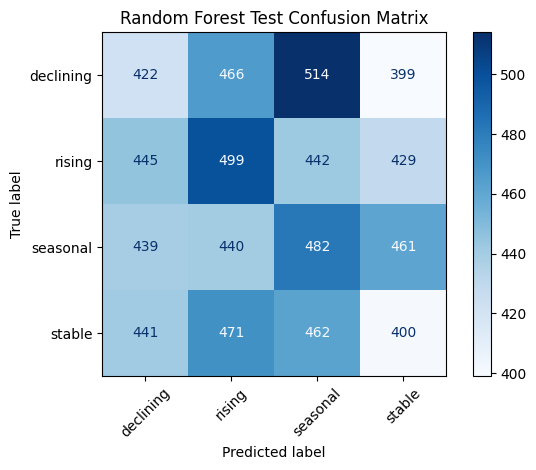


=== MLP Neural Network ===
              precision    recall  f1-score   support

   declining      0.251     0.278     0.264      1801
      rising      0.254     0.291     0.271      1815
    seasonal      0.244     0.228     0.235      1822
      stable      0.267     0.215     0.238      1774

    accuracy                          0.253      7212
   macro avg      0.254     0.253     0.252      7212
weighted avg      0.254     0.253     0.252      7212



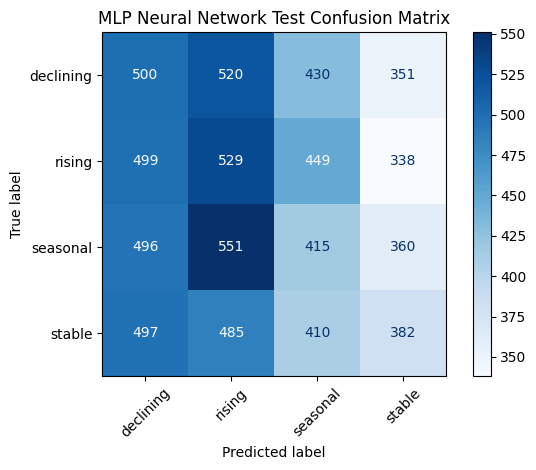

,model,type,accuracy,macro_f1
0,MLP Neural Network,neural_network,0.2532,0.2522
1,Random Forest,traditional,0.2500,0.2496
2,Dummy Majority,baseline,0.2526,0.1008


In [14]:
best_traditional = validation_results[validation_results["type"] == "traditional"].iloc[0]["model"]
final_model_names = ["Dummy Majority", best_traditional, "MLP Neural Network"]

final_rows = []
for model_name in final_model_names:
    model = trained_models[model_name]
    y_pred = model.predict(X_test)

    final_rows.append({
        "model": model_name,
        "type": models[model_name]["type"],
        "accuracy": accuracy_score(y_test, y_pred),
        "macro_f1": f1_score(y_test, y_pred, average="macro"),
    })

    print()
    print("===", model_name, "===")
    print(classification_report(y_test, y_pred, digits=3, zero_division=0))

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        xticks_rotation=45,
        cmap="Blues",
    )
    plt.title(f"{model_name} Test Confusion Matrix")
    plt.tight_layout()
    plt.show()

final_results = pd.DataFrame(final_rows).sort_values("macro_f1", ascending=False).reset_index(drop=True)
display(final_results.round(4))

## 6. Summary

This notebook compares traditional machine learning models against a neural network using the same full encoded feature matrix. This is the cleanest setup for RQ3 because it keeps the feature input constant and changes only the model. Feature-group comparison belongs in RQ2; combining feature-group experiments with model comparison here would make the interpretation less clear.

The best validation model is `Random Forest` with validation accuracy 0.2528 and validation macro F1 0.2527. The best traditional model selected for final testing is `Random Forest`. The MLP neural network reaches validation accuracy 0.2515 and validation macro F1 0.2503.

On the test set, `Random Forest` reaches accuracy 0.2500 and macro F1 0.2496. The MLP neural network reaches accuracy 0.2532 and macro F1 0.2522. These values are close to the 0.25 chance-level expectation for a balanced four-class problem.

Overall answer to RQ3: the neural network does not clearly outperform the best traditional model. Since both traditional and neural-network results remain close to chance, the added complexity of the neural network is not justified by the current results. The main limitation appears to be weak predictive signal in the available features rather than the choice of model alone.